# Praktikum Data Science
## Nama:Reno Miftahudin Nim: 123240248 Kelas:IF-I

## Clustering: K-Means dan Hierarchical Clustering

**Studi Kasus:** Segmentasi Negara untuk Prioritas Bantuan Internasional
**Dataset:** Country-data.csv (Unsupervised Learning on Country Data, Kaggle)

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

## 2. Load Dataset

Muat dataset Country-data.csv ke dalam DataFrame.

**Tugas:**
- Baca dataset.
- Tampilkan 5 baris pertama.
- Tampilkan informasi umum dataset.

In [2]:
df = pd.read_csv('Country-data.csv')

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 3. Exploratory Data Analysis (EDA)

Lakukan pemeriksaan awal terhadap dataset.

**Minimal lakukan:**
- ukuran dataset;
- tipe data;
- missing value;
- data duplikat;
- statistik deskriptif;
- distribusi fitur numerik (histogram/boxplot).

In [3]:
print("Ukuran dataset:", df.shape)
print("Jumlah data:", df.shape[0])
print("Jumlah fitur:", df.shape[1])

Ukuran dataset: (167, 10)
Jumlah data: 167
Jumlah fitur: 10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 14.5 KB


In [5]:
print("Jumlah missing value setiap kolom:")
print(df.isnull().sum())

Jumlah missing value setiap kolom:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [6]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [7]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


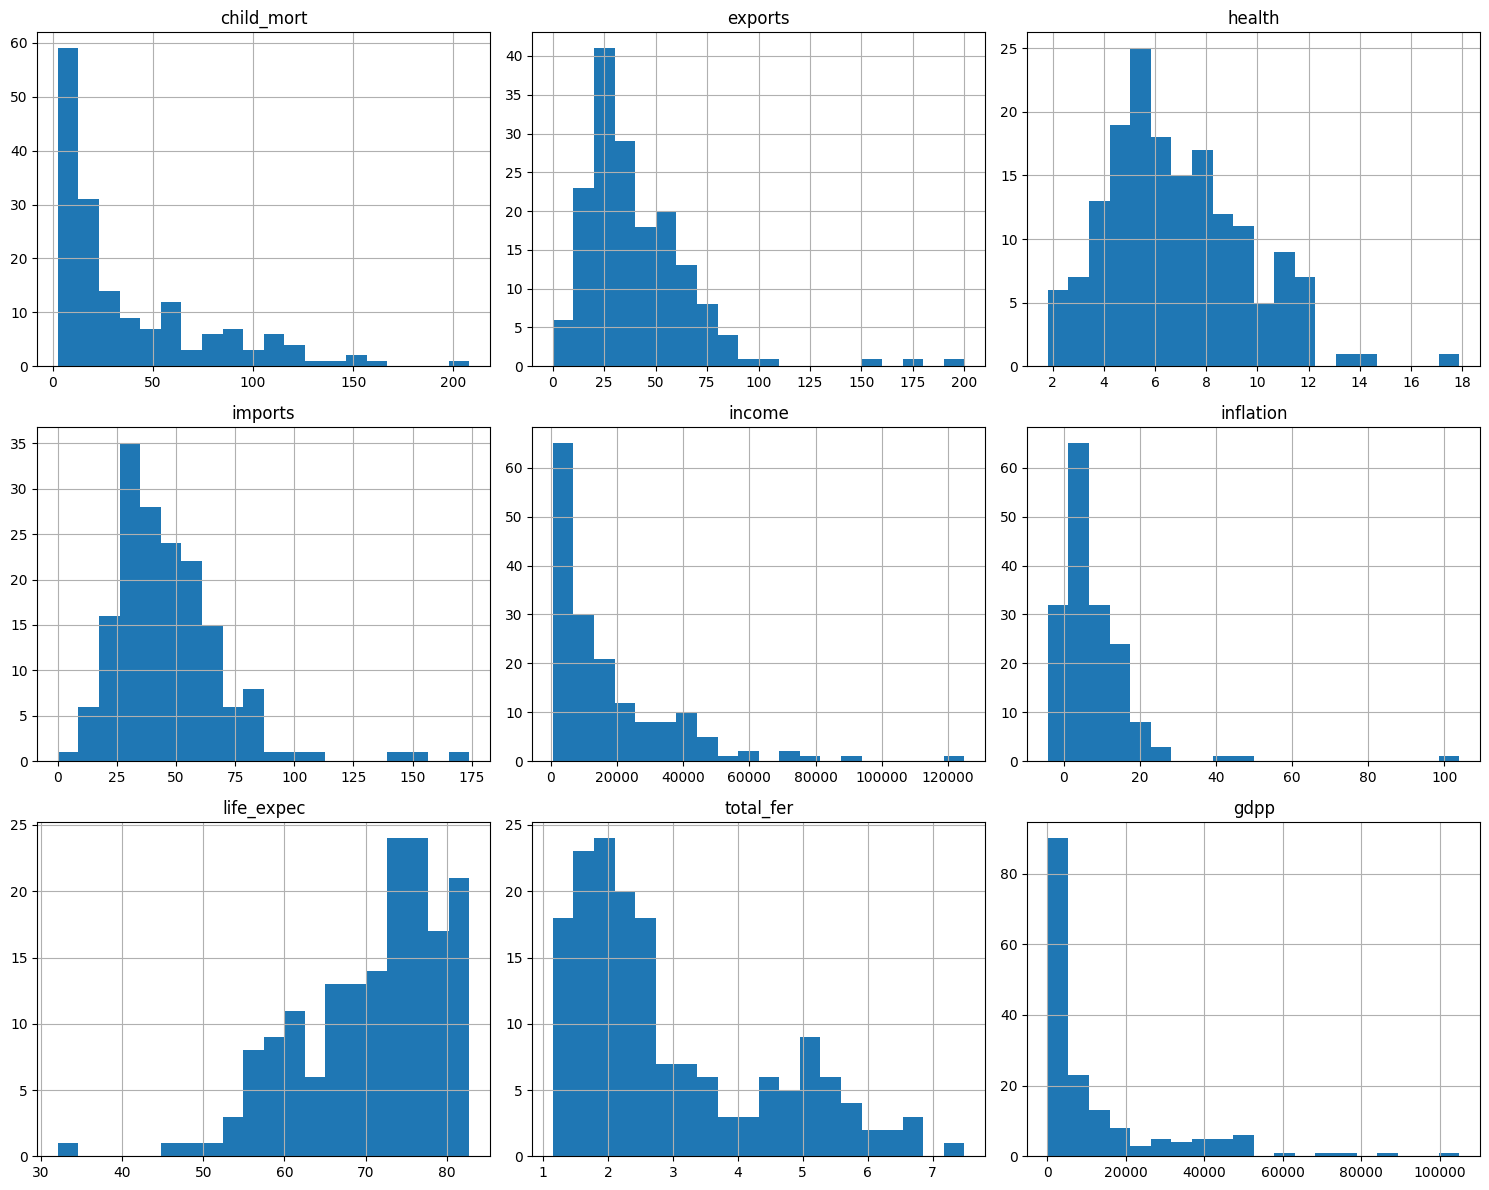

In [25]:
numeric_cols = [
    'child_mort',
    'exports',
    'health',
    'imports',
    'income',
    'inflation',
    'life_expec',
    'total_fer',
    'gdpp'
]

df[numeric_cols].hist(figsize=(15, 12), bins=20)

plt.tight_layout()
plt.show()

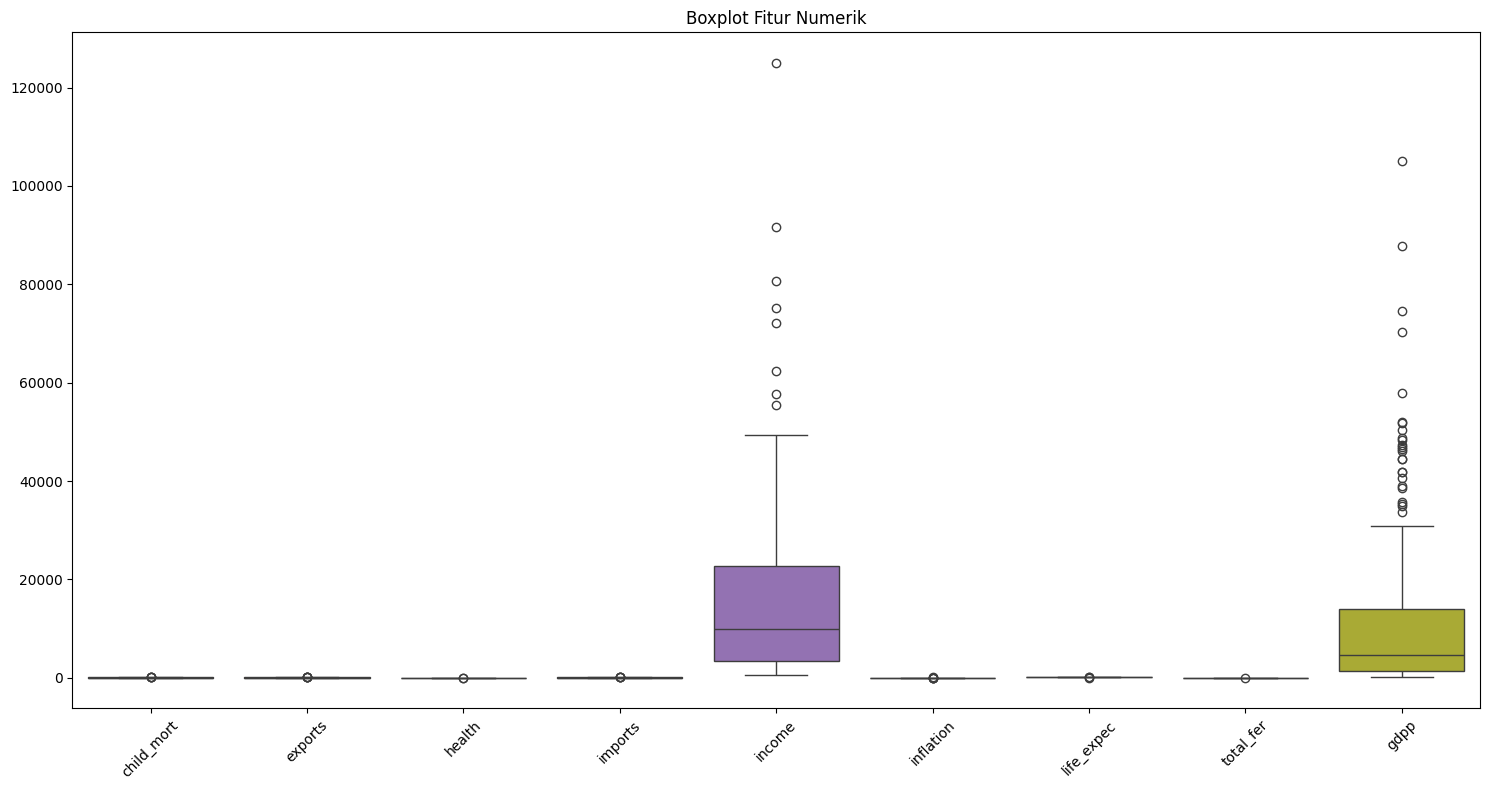

In [26]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)
plt.title("Boxplot Fitur Numerik")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

Lakukan preprocessing sesuai kondisi dataset.

**Periksa dan tangani jika diperlukan:**
- missing value;
- data duplikat/redundan;
- outlier;
- data yang tidak sesuai.

Fitur numerik yang tersedia: child_mort, exports, health, imports, income, inflation, life_expec, total_fer, gdpp.

In [27]:
print("Missing value setiap fitur:")
print(df[numeric_cols].isnull().sum())

Missing value setiap fitur:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [28]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


In [29]:
print("Jumlah nilai negatif:")
print((df[numeric_cols] < 0).sum())

Jumlah nilai negatif:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     8
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [30]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = (
    (df[numeric_cols] < lower_bound) |
    (df[numeric_cols] > upper_bound)
).sum()

print("Jumlah outlier setiap fitur:")
print(outlier_count)

Jumlah outlier setiap fitur:
child_mort     4
exports        5
health         2
imports        4
income         8
inflation      5
life_expec     3
total_fer      1
gdpp          25
dtype: int64


### Penanganan Outlier

Berdasarkan pemeriksaan menggunakan metode IQR, terdapat beberapa nilai yang terdeteksi sebagai outlier. Nilai tersebut tetap dipertahankan karena belum terdapat indikasi bahwa nilai tersebut merupakan kesalahan data. Nilai ekstrem dapat merepresentasikan karakteristik nyata suatu negara dan masih relevan untuk proses clustering.

## 5. Feature Selection

Tentukan fitur numerik yang digunakan untuk proses clustering. Jangan gunakan country (nama negara) sebagai fitur clustering.

**Tuliskan alasan singkat pemilihan fitur.**

In [31]:
X = df[numeric_cols].copy()

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


### Feature Selection

Fitur yang digunakan dalam proses clustering adalah `child_mort`, `exports`, `health`, `imports`, `income`, `inflation`, `life_expec`, `total_fer`, dan `gdpp`. Fitur `country` tidak digunakan karena merupakan identitas/nama negara, bukan karakteristik numerik untuk proses clustering.

## 6. Scaling

Lakukan standardisasi terhadap fitur yang telah dipilih.

> **Penting:** hasil scaling pada bagian ini akan digunakan kembali untuk **K-Means dan Hierarchical Clustering**. Jangan membuat scaling terpisah untuk masing-masing metode.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=numeric_cols)

X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [33]:
X_scaled.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02
mean,-3.722904e-17,2.127373e-16,5.504579e-16,2.765585e-16,-7.977650e-17,-1.063687e-17,3.696311e-16,3.044803e-16,5.850277e-17
std,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00
min,-8.871383e-01,-1.500192e+00,-1.827827e+00,-1.939940e+00,-8.603259e-01,-1.137852e+00,-4.337186e+00,-1.191250e+00,-6.968005e-01
25%,-7.466190e-01,-6.333367e-01,-6.922106e-01,-6.914785e-01,-7.174558e-01,-5.666409e-01,-5.927576e-01,-7.639023e-01,-6.366596e-01
50%,-4.717981e-01,-2.235279e-01,-1.810007e-01,-1.487432e-01,-3.738080e-01,-2.269504e-01,2.869576e-01,-3.564309e-01,-4.544309e-01
75%,5.926666e-01,3.747198e-01,6.515412e-01,4.913530e-01,2.942370e-01,2.816364e-01,7.042584e-01,6.175252e-01,5.942100e-02
max,4.221297e+00,5.813835e+00,4.047436e+00,5.266181e+00,5.611542e+00,9.129718e+00,1.380962e+00,3.009349e+00,5.036507e+00


# A. K-MEANS CLUSTERING
## 7. Menentukan Jumlah Cluster dengan Elbow Method

Gunakan Elbow Method untuk membantu menentukan jumlah cluster yang sesuai.

**Output:**
- grafik Elbow Method;
- kandidat jumlah cluster.

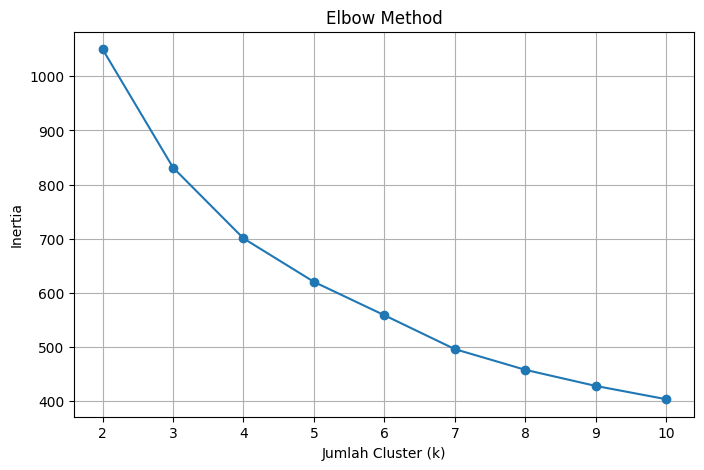

In [34]:
inertia = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### Analisis Elbow Method

Berdasarkan grafik Elbow Method, penurunan inertia terlihat cukup besar dari k=2 hingga k=4. Setelah k=4, penurunan inertia mulai lebih landai. Oleh karena itu, k=4 dipilih sebagai kandidat jumlah cluster untuk proses K-Means.

## 8. Implementasi K-Means

Terapkan K-Means menggunakan jumlah cluster yang dipilih berdasarkan analisis sebelumnya.

**Output:**
- label cluster;
- jumlah anggota setiap cluster.

In [35]:
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

cluster_kmeans = kmeans.fit_predict(X_scaled)

df_kmeans = df.copy()
df_kmeans['cluster'] = cluster_kmeans

df_kmeans.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


In [36]:
df_kmeans['cluster'].value_counts().sort_index()

cluster
0    32
1    47
2    85
3     3
Name: count, dtype: int64

## 9. Evaluasi K-Means dengan Silhouette Score

Hitung Silhouette Score dari hasil K-Means.

**Tuliskan interpretasi singkat terhadap nilai yang diperoleh.**

In [37]:
from sklearn.metrics import silhouette_score

silhouette_kmeans = silhouette_score(X_scaled, cluster_kmeans)

print("Silhouette Score K-Means:", silhouette_kmeans)

Silhouette Score K-Means: 0.29595170577528157


### Interpretasi Silhouette Score

Hasil evaluasi K-Means menghasilkan Silhouette Score sebesar 0,29595. Nilai tersebut menunjukkan bahwa pemisahan antar-cluster masih belum terlalu kuat. Meskipun demikian, hasil clustering tetap dapat digunakan untuk melihat pola pengelompokan negara berdasarkan fitur yang digunakan.

## 10. Visualisasi Hasil K-Means

Buat visualisasi yang sesuai untuk membantu melihat pembagian cluster. Jika jumlah fitur lebih dari dua, pilih pendekatan visualisasi yang sesuai dengan materi praktikum (misalnya scatter plot 2 fitur paling relevan).

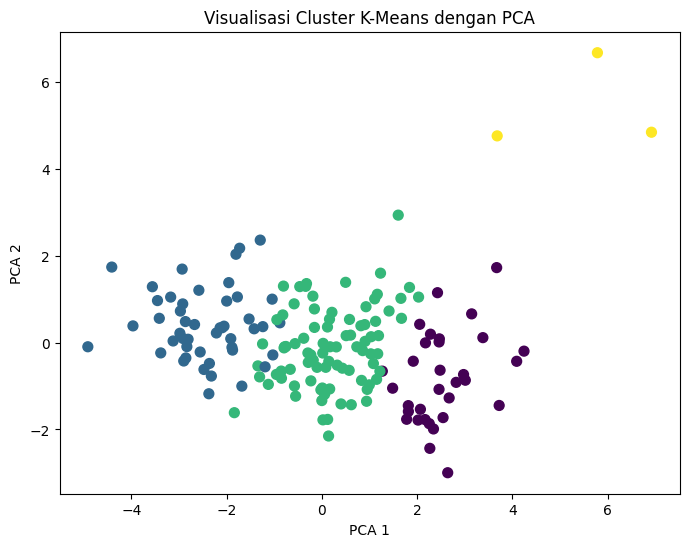

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_kmeans,
    s=50
)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualisasi Cluster K-Means dengan PCA')
plt.show()

## 11. Profil dan Interpretasi Cluster K-Means

Hitung nilai rata-rata fitur pada setiap cluster.

**Buat tabel profil cluster dan berikan deskripsi singkat karakteristik masing-masing cluster.**

In [39]:
# Profil dan Interpretasi Cluster K-Means

cluster_profile = df_kmeans.groupby('cluster')[numeric_cols].mean()

print("Rata-rata fitur pada setiap cluster:")
display(cluster_profile.round(2))

print("\nJumlah anggota setiap cluster:")
print(df_kmeans['cluster'].value_counts().sort_index())

Rata-rata fitur pada setiap cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.69,41.07,6.20,47.91,12671.41,7.61,72.87,2.30,6519.55
3,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67



Jumlah anggota setiap cluster:
cluster
0    32
1    47
2    85
3     3
Name: count, dtype: int64


### Pertanyaan Analisis K-Means
**1.** Berdasarkan Elbow Method dan Silhouette Score, berapa jumlah cluster yang digunakan? Jelaskan dasar pemilihannya.

**2.** Bagaimana karakteristik utama dari setiap cluster?

1. Berdasarkan Elbow Method, jumlah cluster yang digunakan adalah 4. Pada grafik Elbow, penurunan inertia terlihat cukup besar hingga k=4 dan setelahnya mulai lebih landai. K=4 kemudian digunakan dalam K-Means dan menghasilkan Silhouette Score sebesar 0,29595. Nilai tersebut menunjukkan bahwa pemisahan antar-cluster masih belum terlalu kuat, tetapi hasil clustering tetap dapat digunakan untuk melihat pola pengelompokan negara berdasarkan fitur yang digunakan.
2. Cluster 0 terdiri dari 32 negara dengan income dan gdpp yang tinggi, child_mort rendah, serta life_expec tinggi.
Cluster 1 terdiri dari 47 negara dengan child_mort sangat tinggi, income dan gdpp rendah, serta life_expec rendah.
Cluster 2 merupakan cluster terbesar dengan 85 negara. Nilai income, gdpp, child_mort, dan life_expec berada pada tingkat menengah dibandingkan cluster lainnya.
Cluster 3 hanya terdiri dari 3 negara. Cluster ini memiliki exports, imports, income, dan gdpp yang paling tinggi, serta child_mort rendah dan life_expec tinggi.

# B. HIERARCHICAL CLUSTERING
Gunakan **dataset dan hasil preprocessing/scaling yang sama** seperti pada K-Means.

## 12. Agglomerative Clustering dengan Beberapa Linkage

Coba beberapa linkage yang telah dipelajari:
- Ward
- Average
- Complete
- Single

Gunakan jumlah cluster yang sama terlebih dahulu untuk melakukan perbandingan yang adil.

In [ ]:
from sklearn.cluster import AgglomerativeClustering

linkages = ['ward', 'average', 'complete', 'single']

hierarchical_results = {}

for linkage_method in linkages:
    model = AgglomerativeClustering(
        n_clusters=4,
        linkage=linkage_method
    )
    
    labels = model.fit_predict(X_scaled)
    
    hierarchical_results[linkage_method] = labels

print("Agglomerative clustering selesai untuk:")
for linkage_method in linkages:aa
    print("-", linkage_method)s

Agglomerative clustering selesai untuk:
- ward
- average
- complete
- single


## 13. Perbandingan Silhouette Score

Hitung dan tampilkan Silhouette Score untuk:
- Ward
- Average
- Complete
- Single

Buat tabel perbandingan agar hasil mudah dibaca.

In [41]:
silhouette_hierarchical = {}

for linkage_method, labels in hierarchical_results.items():
    score = silhouette_score(X_scaled, labels)
    silhouette_hierarchical[linkage_method] = score

print("Silhouette Score setiap linkage:")

for linkage_method, score in silhouette_hierarchical.items():
    print(f"{linkage_method}: {score:.4f}")

Silhouette Score setiap linkage:
ward: 0.2481
average: 0.4970
complete: 0.2864
single: 0.5348


## 14. Dendrogram – Ward

Buat dendrogram menggunakan linkage **Ward**.

Gunakan dendrogram untuk menentukan jumlah cluster yang wajar berdasarkan struktur penggabungan cluster.

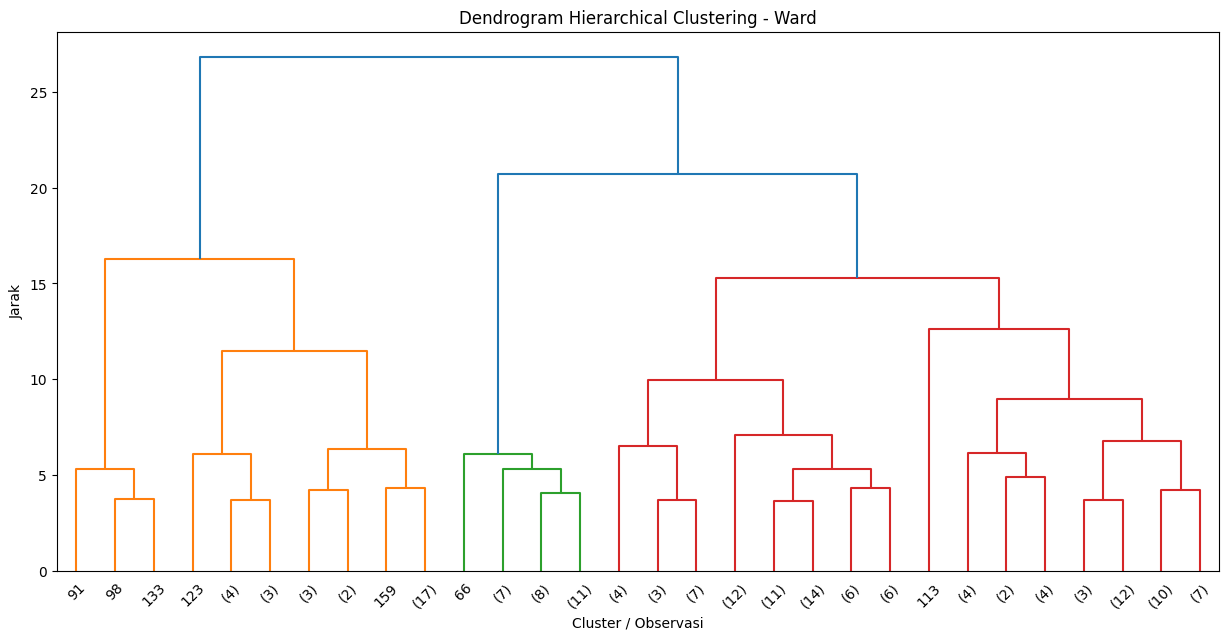

In [42]:
from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(15, 7))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30
)

plt.title('Dendrogram Hierarchical Clustering - Ward')
plt.xlabel('Cluster / Observasi')
plt.ylabel('Jarak')
plt.show()

## 15. Menentukan Jumlah Cluster dari Dendrogram

Tuliskan:
- ketinggian pemotongan yang digunakan (jika digunakan);
- jumlah cluster yang diperoleh;
- alasan pemilihan jumlah cluster.

In [43]:
from scipy.cluster.hierarchy import fcluster

# Menentukan 4 cluster berdasarkan dendrogram
n_clusters_hierarchical = 4

hierarchical_labels = fcluster(
    Z,
    t=n_clusters_hierarchical,
    criterion='maxclust'
)

print("Jumlah cluster:", n_clusters_hierarchical)
print("\nJumlah anggota setiap cluster:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

Jumlah cluster: 4

Jumlah anggota setiap cluster:
1      3
2     31
3     27
4    106
Name: count, dtype: int64


### Penentuan Jumlah Cluster

Berdasarkan dendrogram Ward, garis pemotongan dapat ditempatkan pada kisaran jarak 15 sehingga menghasilkan 4 kelompok. Oleh karena itu, jumlah cluster yang digunakan pada Hierarchical Clustering adalah 4 cluster.

## 16. Heatmap Cluster

Buat heatmap fitur yang telah distandarisasi dan diurutkan berdasarkan label cluster.

Gunakan heatmap untuk membantu melihat fitur yang membedakan karakteristik antar-cluster.

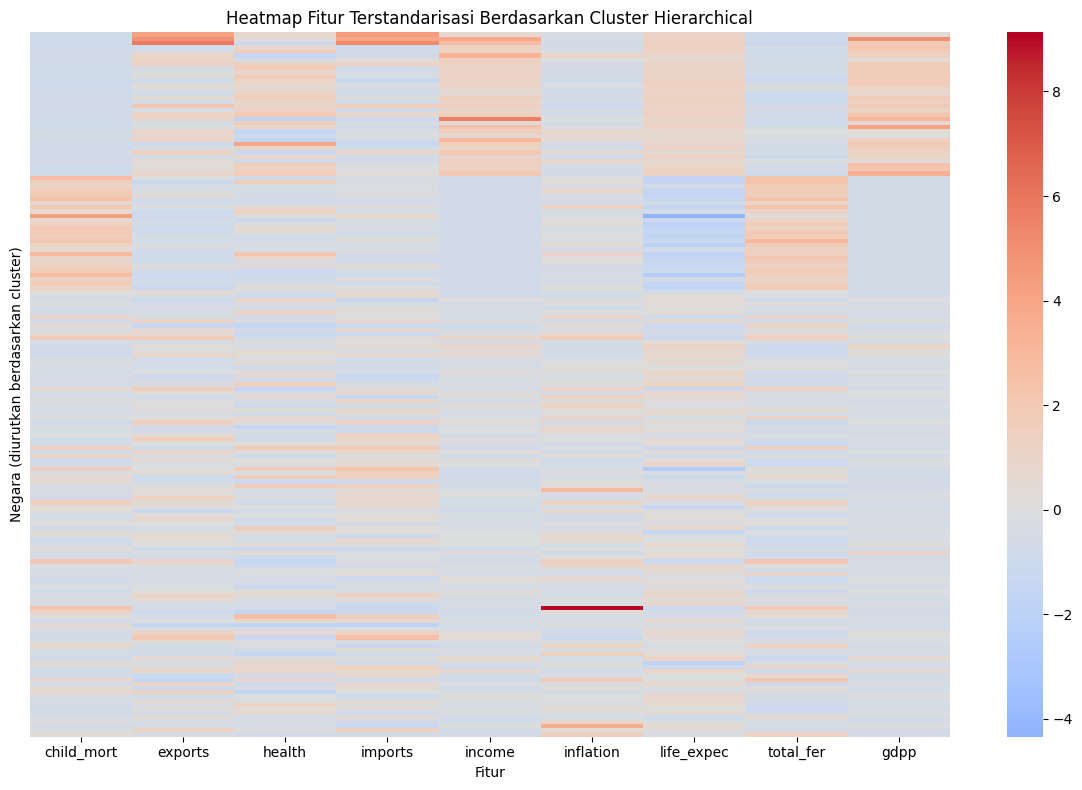

Jumlah anggota setiap cluster:
1      3
2     31
3     27
4    106
Name: count, dtype: int64


In [44]:
heatmap_data = X_scaled.copy()
heatmap_data['cluster'] = hierarchical_labels

# Urutkan data berdasarkan cluster
heatmap_data = heatmap_data.sort_values('cluster')

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data.drop(columns='cluster'),
    cmap='coolwarm',
    center=0,
    yticklabels=False
)

plt.title('Heatmap Fitur Terstandarisasi Berdasarkan Cluster Hierarchical')
plt.xlabel('Fitur')
plt.ylabel('Negara (diurutkan berdasarkan cluster)')
plt.tight_layout()
plt.show()

print("Jumlah anggota setiap cluster:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

## 17. Profil dan Interpretasi Cluster Hierarchical

Buat tabel profil cluster berdasarkan nilai rata-rata fitur.

Jelaskan karakteristik masing-masing cluster.

In [45]:

df_hierarchical = df.copy()
df_hierarchical['cluster'] = hierarchical_labels

# Menghitung rata-rata setiap fitur berdasarkan cluster
hierarchical_profile = df_hierarchical.groupby('cluster')[numeric_cols].mean()

print("Rata-rata fitur pada setiap cluster:")
display(hierarchical_profile.round(2))

print("\nJumlah anggota setiap cluster:")
print(df_hierarchical['cluster'].value_counts().sort_index())

Rata-rata fitur pada setiap cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
1,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67
2,6.14,47.14,8.67,38.47,45996.77,4.27,79.84,1.94,41777.42
3,105.07,23.59,6.51,39.66,1589.74,7.14,57.25,5.43,667.89
4,31.62,39.99,6.35,48.09,11341.89,9.12,70.92,2.65,6407.37



Jumlah anggota setiap cluster:
cluster
1      3
2     31
3     27
4    106
Name: count, dtype: int64


### Pertanyaan Analisis Hierarchical
**1.** Linkage mana yang menghasilkan Silhouette Score paling tinggi? Jelaskan apa yang dapat ditunjukkan oleh hasil tersebut.

**2.** Berdasarkan dendrogram Ward, berapa jumlah cluster yang menurutmu paling wajar? Jelaskan dasar pemilihannya.

1. Berdasarkan hasil perbandingan Silhouette Score, metode Single Linkage menghasilkan nilai tertinggi yaitu 0,5348. Selanjutnya Average Linkage memperoleh nilai 0,4970, Complete Linkage sebesar 0,2864, dan Ward sebesar 0,2481.
Silhouette Score digunakan untuk melihat seberapa baik pemisahan antar-cluster. Nilai yang lebih tinggi menunjukkan bahwa objek dalam cluster cenderung lebih dekat dengan cluster-nya sendiri dan lebih terpisah dari cluster lainnya. Dengan demikian, pada pengujian menggunakan 4 cluster, Single Linkage menghasilkan pemisahan cluster dengan nilai Silhouette Score paling tinggi dibandingkan tiga linkage lainnya.
2. Berdasarkan dendrogram Ward, jumlah cluster yang digunakan adalah 4 cluster. Pemilihan tersebut didasarkan pada struktur penggabungan pada dendrogram, di mana terdapat peningkatan jarak penggabungan yang cukup besar sebelum seluruh kelompok menjadi satu cluster. Dengan melakukan pemotongan dendrogram pada kisaran jarak tersebut, diperoleh 4 kelompok.
Jumlah 4 cluster juga digunakan agar dapat dibandingkan secara konsisten dengan hasil K-Means yang sebelumnya menggunakan 4 cluster.

# C. PERBANDINGAN K-MEANS DAN HIERARCHICAL

Kedua algoritma diterapkan pada dataset dan hasil preprocessing yang sama.

## 18. Perbandingan Hasil

Bandingkan hasil K-Means dan Hierarchical berdasarkan jumlah cluster, pembagian data, atau karakteristik cluster yang terbentuk.

In [46]:
perbandingan = pd.DataFrame({
    'Metode': ['K-Means', 'Hierarchical - Ward'],
    'Jumlah Cluster': [4, 4],
    'Silhouette Score': [
        silhouette_kmeans,
        silhouette_hierarchical['ward']
    ]
})

display(perbandingan.round(4))

,Metode,Jumlah Cluster,Silhouette Score
0,K-Means,4,0.2960
1,Hierarchical - Ward,4,0.2481


### Pertanyaan Analisis Perbandingan
**1.** Apa perbedaan utama hasil K-Means dan Hierarchical Clustering pada dataset yang sama? Jelaskan berdasarkan jumlah cluster, pembagian data, atau karakteristik cluster yang terbentuk.

K-Means dan Hierarchical Clustering diterapkan pada dataset dan preprocessing yang sama, tetapi menghasilkan pembagian data yang berbeda. K-Means menggunakan 4 cluster dengan jumlah anggota masing-masing 32, 47, 85, dan 3 negara. Sementara itu, Hierarchical Clustering dengan metode Ward juga menggunakan 4 cluster, tetapi jumlah anggotanya adalah 3, 31, 27, dan 106 negara.

Perbedaan tersebut terjadi karena kedua metode memiliki cara pembentukan cluster yang berbeda. K-Means mengelompokkan data berdasarkan kedekatannya terhadap centroid, sedangkan Hierarchical Clustering membentuk cluster secara bertahap melalui proses penggabungan berdasarkan jarak.

Perbedaan pembagian data tersebut juga menyebabkan karakteristik cluster yang terbentuk berbeda, meskipun dataset, fitur, dan preprocessing yang digunakan sama.

# D. KESIMPULAN

Tuliskan kesimpulan singkat berdasarkan:
1. hasil K-Means;
2. hasil Hierarchical Clustering;
3. perbedaan hasil kedua metode.

### Kesimpulan

1. **Hasil K-Means**

K-Means menggunakan 4 cluster berdasarkan analisis Elbow Method. Hasil clustering menghasilkan 32, 47, 85, dan 3 negara pada masing-masing cluster. Silhouette Score yang diperoleh adalah 0,29595.

2. **Hasil Hierarchical Clustering**

Hierarchical Clustering menggunakan metode Ward dengan 4 cluster berdasarkan analisis dendrogram. Hasil clustering menghasilkan 3, 31, 27, dan 106 negara pada masing-masing cluster. Silhouette Score Ward yang diperoleh adalah 0,2481.

Selain Ward, dilakukan perbandingan beberapa linkage. Silhouette Score yang diperoleh adalah 0,2481 untuk Ward, 0,4970 untuk Average, 0,2864 untuk Complete, dan 0,5348 untuk Single.

3. **Perbedaan Hasil Kedua Metode**

K-Means dan Hierarchical Clustering menggunakan dataset, fitur, dan preprocessing yang sama, tetapi menghasilkan pembagian anggota cluster yang berbeda. K-Means menghasilkan pembagian 32, 47, 85, dan 3 negara, sedangkan Hierarchical Ward menghasilkan 3, 31, 27, dan 106 negara. Perbedaan tersebut terjadi karena K-Means membentuk cluster berdasarkan kedekatan data terhadap centroid, sedangkan Hierarchical Clustering membentuk cluster secara bertahap berdasarkan proses penggabungan data.sslssaqlawrssasa